# Notebook 9 — Interactive Pacific Nutrition Transition Explorer (prototype)

# Section 1. Introduction

## Purpose

The purpose of this notebook is to provide an interactive interface for exploring the Pacific Nutrition Transition Observatory.

Unlike the previous notebooks, which focused on data acquisition, processing, integration, and exploratory analysis, this notebook emphasizes exploration and communication. Users can interactively examine food system, demographic, and metabolic health indicators across Pacific Island jurisdictions, compare countries, and visualize long-term trends.

The dashboard is intended to support hypothesis generation, public health surveillance, and presentation of the integrated observatory dataset.

---

## Objectives

This notebook will:

1. Load the completed Pacific Nutrition Transition Observatory dataset.
2. Allow users to select one or more Pacific Island jurisdictions.
3. Display interactive visualizations of food system, demographic, and metabolic health indicators.
4. Compare countries across time.
5. Explore relationships between food system indicators and metabolic health outcomes.

In [10]:
# Import required libraries

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from IPython.display import display

print("Notebook initialized successfully.")

Notebook initialized successfully.


# Section 2. Load the Observatory Dataset

The Pacific Nutrition Transition Observatory is the integrated master dataset created in the previous notebooks. It combines food system, metabolic health, and demographic indicators into a single analytical dataset covering 16 Pacific Island jurisdictions.

This section loads the dataset and performs a brief validation to confirm that the expected structure is available before interactive exploration begins.

In [11]:
# Load the observatory dataset

observatory = pd.read_csv(
    "pacific_nutrition_transition_observatory.csv"
)

print("Dataset loaded successfully.\n")

print(f"Rows: {observatory.shape[0]}")
print(f"Columns: {observatory.shape[1]}\n")

print("Columns:")
print(list(observatory.columns))

print("\nCountries:")
print(sorted(observatory["Country"].unique()))

print("\nYear range:")
print(
    f"{observatory['Year'].min()} to "
    f"{observatory['Year'].max()}"
)

Dataset loaded successfully.

Rows: 720
Columns: 26

Columns:
['ISO3', 'Country', 'Year', 'Underweight_Pct', 'HealthyWeight_Pct', 'Overweight_Pct', 'Obesity_Pct', 'Class1_Obesity_Pct', 'Class2_Obesity_Pct', 'Morbid_Obesity_Pct', 'Diabetes_Pct', 'Diabetes_Treated_Pct', 'Hypertension_Pct', 'Hypertension_Diagnosed_Pct', 'Hypertension_Treated_Pct', 'Hypertension_Controlled_Pct', 'Untreated_Stage2_Pct', 'Dietary_Energy_kcal', 'Fat_g', 'Protein_g', 'Food_Imports_Export_Value_Pct', 'Population', 'Population_Thousands', 'Population_Density', 'Median_Age', 'Population_Growth_Rate']

Countries:
['American Samoa', 'Cook Islands', 'Federated States of Micronesia', 'Fiji', 'French Polynesia', 'Kiribati', 'Marshall Islands', 'Nauru', 'Niue', 'Palau', 'Samoa', 'Solomon Islands', 'Tokelau', 'Tonga', 'Tuvalu', 'Vanuatu']

Year range:
1980 to 2024


# Section 3. Explorer Controls

Select a Pacific Island jurisdiction to explore. The selected country will be used throughout the remainder of the notebook to generate country profiles, trend visualizations, comparisons, and other interactive analyses.

Changing the selected country and re-running subsequent sections will update all figures and summaries.

In [12]:
import ipywidgets as widgets
from IPython.display import display

# Create country list
countries = ["Select a country..."] + sorted(observatory["Country"].unique())

# Country selector
country_dropdown = widgets.Dropdown(
    options=countries,
    value="Select a country...",
    description="Country:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="400px")
)

display(country_dropdown)

Dropdown(description='Country:', layout=Layout(width='400px'), options=('Select a country...', 'American Samoa…

# Section 4. Country Profile

Display a summary profile for the selected Pacific Island jurisdiction.

The profile reports the available time span, the most recent demographic indicators, and the latest available food system and metabolic health measurements before exploring trends over time.

In [15]:
# Check that a country has been selected

selected_country = country_dropdown.value

if selected_country == "Select a country...":
    print("Please select a country from the dropdown above.")

else:

    country = observatory[
        observatory["Country"] == selected_country
    ].sort_values("Year")

    latest = country.iloc[-1]

    print("=" * 60)
    print(selected_country)
    print("=" * 60)

    print(f"Years available: {country['Year'].min()}–{country['Year'].max()}")

    print("\nLatest demographic indicators")
    print(f"Population: {latest['Population']:,.0f}")
    print(f"Median age: {latest['Median_Age']:.1f}")
    print(f"Population growth: {latest['Population_Growth_Rate']:.2f}%")

    print("\nLatest metabolic health indicators")
    print(f"Obesity: {latest['Obesity_Pct']:.1f}%")

    if pd.notna(latest["Diabetes_Pct"]):
        print(f"Diabetes: {latest['Diabetes_Pct']*100:.1f}%")

    if pd.notna(latest["Hypertension_Pct"]):
        print(f"Hypertension: {latest['Hypertension_Pct']*100:.1f}%")

    print("\nLatest food system indicators")

    if pd.notna(latest["Dietary_Energy_kcal"]):
        print(f"Dietary energy: {latest['Dietary_Energy_kcal']:.0f} kcal/day")

    if pd.notna(latest["Fat_g"]):
        print(f"Fat supply: {latest['Fat_g']:.1f} g/day")

    if pd.notna(latest["Protein_g"]):
        print(f"Protein supply: {latest['Protein_g']:.1f} g/day")

    if pd.notna(latest["Food_Imports_Export_Value_Pct"]):
        print(f"Food imports: {latest['Food_Imports_Export_Value_Pct']:.1f}%")

Fiji
Years available: 1980–2024

Latest demographic indicators
Population: nan
Median age: nan
Population growth: nan%

Latest metabolic health indicators
Obesity: 40.1%

Latest food system indicators


# Section 5. Country Trends

Explore long-term trends for the selected jurisdiction.

The panels below summarize changes in metabolic health, food system indicators, and population characteristics over time, allowing users to examine how these measures evolved together.

Fiji Country Dashboard
Years available: 1980–2024

Latest available indicators:
Population: 924,145
Median age: 27.7
Obesity: 40.1%
Diabetes: 23.4%
Hypertension: 38.5%


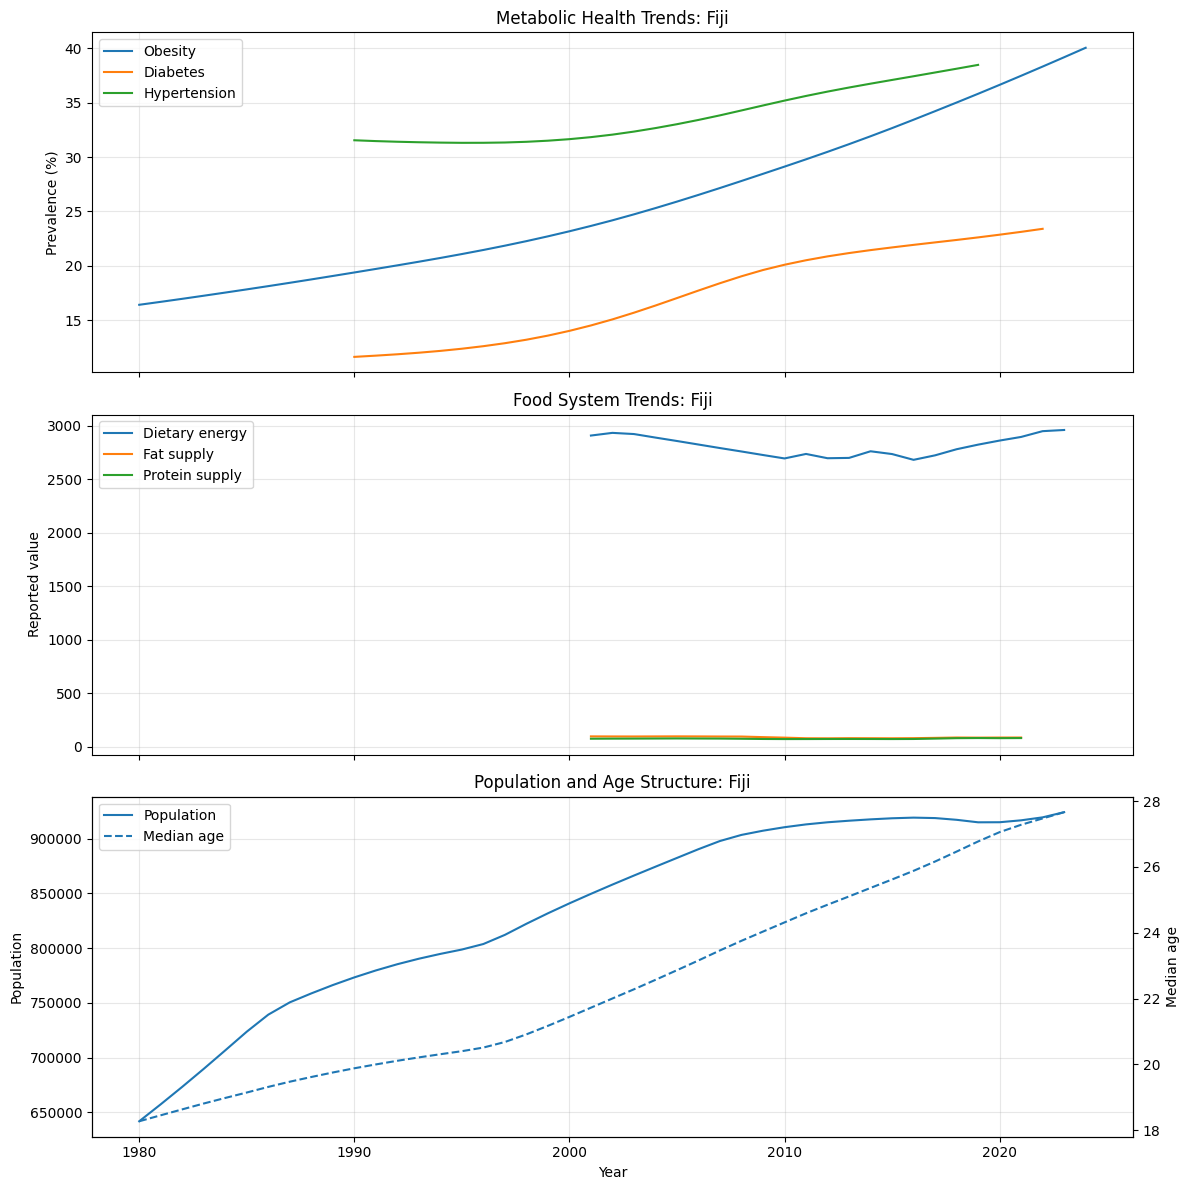

In [16]:
selected_country = country_dropdown.value

if selected_country == "Select a country...":
    print("Please select a country from the dropdown above, then rerun this cell.")

else:
    country = (
        observatory[observatory["Country"] == selected_country]
        .sort_values("Year")
        .copy()
    )

    latest_population = country["Population"].dropna().iloc[-1] if country["Population"].notna().any() else None
    latest_median_age = country["Median_Age"].dropna().iloc[-1] if country["Median_Age"].notna().any() else None
    latest_obesity = country["Obesity_Pct"].dropna().iloc[-1] if country["Obesity_Pct"].notna().any() else None
    latest_diabetes = country["Diabetes_Pct"].dropna().iloc[-1] * 100 if country["Diabetes_Pct"].notna().any() else None
    latest_hypertension = country["Hypertension_Pct"].dropna().iloc[-1] * 100 if country["Hypertension_Pct"].notna().any() else None

    print("=" * 70)
    print(f"{selected_country} Country Dashboard")
    print("=" * 70)

    print(f"Years available: {country['Year'].min()}–{country['Year'].max()}")

    print("\nLatest available indicators:")
    print(f"Population: {latest_population:,.0f}" if latest_population is not None else "Population: unavailable")
    print(f"Median age: {latest_median_age:.1f}" if latest_median_age is not None else "Median age: unavailable")
    print(f"Obesity: {latest_obesity:.1f}%" if latest_obesity is not None else "Obesity: unavailable")
    print(f"Diabetes: {latest_diabetes:.1f}%" if latest_diabetes is not None else "Diabetes: unavailable")
    print(f"Hypertension: {latest_hypertension:.1f}%" if latest_hypertension is not None else "Hypertension: unavailable")

    fig, axes = plt.subplots(
        nrows=3,
        ncols=1,
        figsize=(12, 12),
        sharex=True
    )

    # Panel 1: Metabolic health
    axes[0].plot(country["Year"], country["Obesity_Pct"], label="Obesity")
    axes[0].plot(country["Year"], country["Diabetes_Pct"] * 100, label="Diabetes")
    axes[0].plot(country["Year"], country["Hypertension_Pct"] * 100, label="Hypertension")

    axes[0].set_title(f"Metabolic Health Trends: {selected_country}")
    axes[0].set_ylabel("Prevalence (%)")
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    # Panel 2: Food system
    food_columns = ["Dietary_Energy_kcal", "Fat_g", "Protein_g"]
    food_data_available = country[food_columns].notna().any().any()

    if food_data_available:
        axes[1].plot(country["Year"], country["Dietary_Energy_kcal"], label="Dietary energy")
        axes[1].plot(country["Year"], country["Fat_g"], label="Fat supply")
        axes[1].plot(country["Year"], country["Protein_g"], label="Protein supply")
        axes[1].set_title(f"Food System Trends: {selected_country}")
        axes[1].set_ylabel("Reported value")
        axes[1].grid(alpha=0.3)
        axes[1].legend()

    else:
        axes[1].axis("off")
        axes[1].text(
            0.5,
            0.5,
            f"Food system indicators are unavailable for {selected_country}.",
            ha="center",
            va="center",
            fontsize=12,
            transform=axes[1].transAxes
        )

    # Panel 3: Demographics
    ax_population = axes[2]
    ax_age = ax_population.twinx()

    ax_population.plot(
        country["Year"],
        country["Population"],
        label="Population"
    )

    ax_age.plot(
        country["Year"],
        country["Median_Age"],
        label="Median age",
        linestyle="--"
    )

    ax_population.set_title(f"Population and Age Structure: {selected_country}")
    ax_population.set_xlabel("Year")
    ax_population.set_ylabel("Population")
    ax_age.set_ylabel("Median age")

    ax_population.grid(alpha=0.3)

    lines_1, labels_1 = ax_population.get_legend_handles_labels()
    lines_2, labels_2 = ax_age.get_legend_handles_labels()

    ax_population.legend(
        lines_1 + lines_2,
        labels_1 + labels_2,
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()

# Section 6. Indicator Explorer

Explore one selected indicator at a time for the chosen Pacific Island jurisdiction.

This section allows users to choose a specific metabolic health, food system, or demographic indicator and view its trend over time. This avoids comparing indicators with different units on the same axis and provides a cleaner view of each variable.

In [19]:
indicator_options = {
    "Obesity (%)": ("Obesity_Pct", 1, "%"),
    "Diabetes (%)": ("Diabetes_Pct", 100, "%"),
    "Hypertension (%)": ("Hypertension_Pct", 100, "%"),
    "Dietary energy (kcal/cap/day)": ("Dietary_Energy_kcal", 1, "kcal/cap/day"),
    "Fat supply (g/cap/day)": ("Fat_g", 1, "g/cap/day"),
    "Protein supply (g/cap/day)": ("Protein_g", 1, "g/cap/day"),
    "Food imports (% of merchandise exports)": ("Food_Imports_Export_Value_Pct", 1, "%"),
    "Population": ("Population", 1, "people"),
    "Median age": ("Median_Age", 1, "years"),
    "Population growth rate (%)": ("Population_Growth_Rate", 1, "%")
}

indicator_dropdown = widgets.Dropdown(
    options=["Select an indicator..."] + list(indicator_options.keys()),
    value="Select an indicator...",
    description="Indicator:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="500px")
)

display(indicator_dropdown)

Dropdown(description='Indicator:', layout=Layout(width='500px'), options=('Select an indicator...', 'Obesity (…

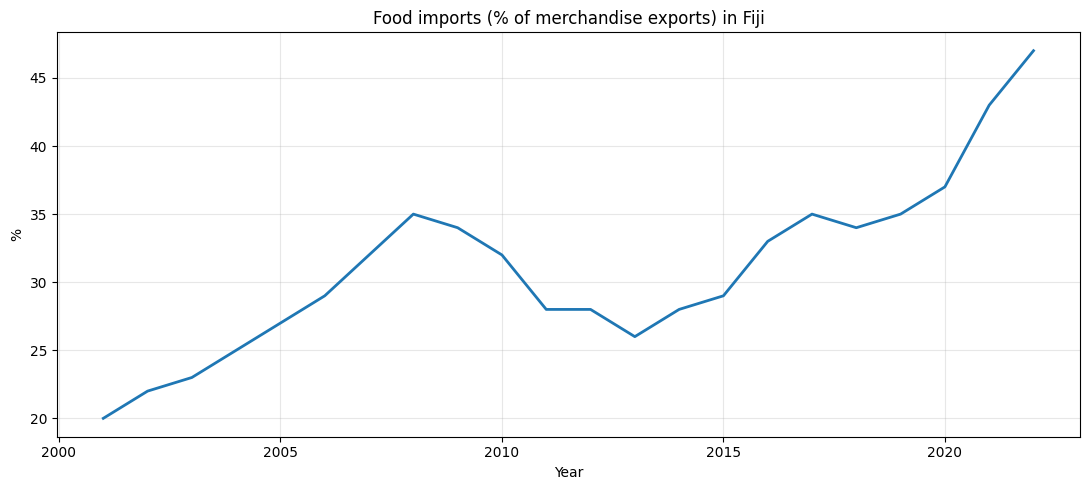

Latest available value:
2022: 47.00 %


In [20]:
selected_country = country_dropdown.value
selected_indicator = indicator_dropdown.value

if selected_country == "Select a country...":
    print("Please select a country from the country dropdown above, then rerun this cell.")

else:
    column, multiplier, unit = indicator_options[selected_indicator]

    country = (
        observatory[observatory["Country"] == selected_country]
        .sort_values("Year")
        .copy()
    )

    plot_data = country[["Year", column]].dropna().copy()

    if plot_data.empty:
        print(f"{selected_indicator} is unavailable for {selected_country}.")

    else:
        plot_data[column] = plot_data[column] * multiplier

        plt.figure(figsize=(11, 5))

        plt.plot(
            plot_data["Year"],
            plot_data[column],
            linewidth=2
        )

        plt.title(f"{selected_indicator} in {selected_country}")
        plt.xlabel("Year")
        plt.ylabel(unit)
        plt.grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

        print("Latest available value:")
        print(f"{plot_data['Year'].iloc[-1]}: {plot_data[column].iloc[-1]:,.2f} {unit}")

# Section 7. Compare Jurisdictions

Compare one selected indicator across multiple Pacific Island jurisdictions.

This section allows users to select several jurisdictions and view their trends on the same chart. It supports direct comparison across countries while keeping the indicator and unit consistent.

In [25]:
comparison_countries = widgets.SelectMultiple(
    options=sorted(observatory["Country"].unique()),
    value=(),
    description="Countries:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="500px", height="180px")
)

comparison_indicator_dropdown = widgets.Dropdown(
    options=["Select an indicator..."] + list(indicator_options.keys()),
    value="Select an indicator...",
    description="Indicator:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="500px")
)

display(comparison_countries)
display(comparison_indicator_dropdown)

SelectMultiple(description='Countries:', layout=Layout(height='180px', width='500px'), options=('American Samo…

Dropdown(description='Indicator:', layout=Layout(width='500px'), options=('Select an indicator...', 'Obesity (…

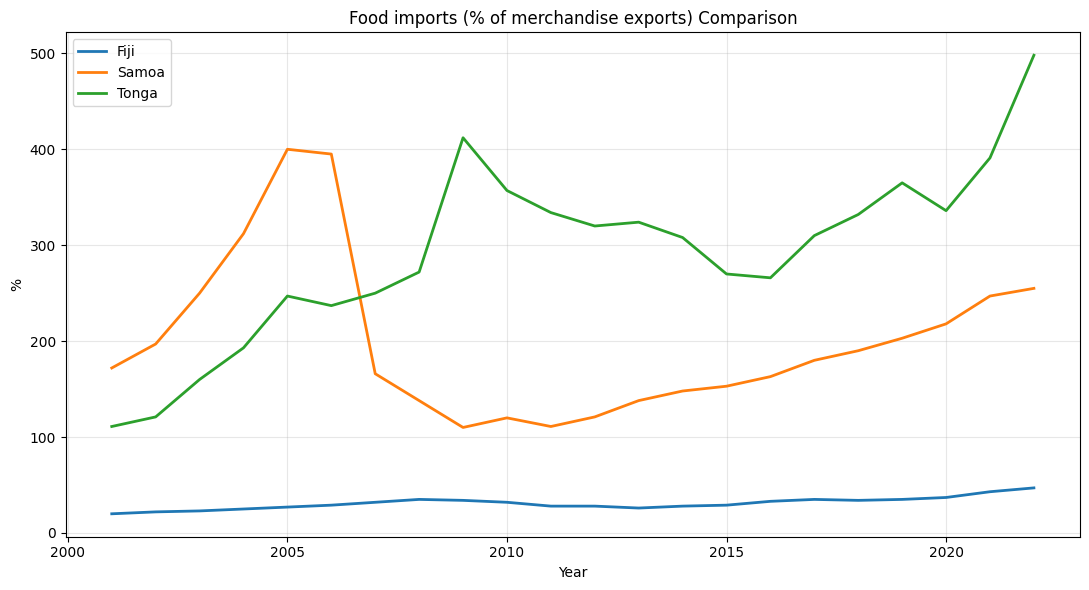

Countries plotted:
- Fiji
- Samoa
- Tonga

Selected countries not plotted because this indicator is unavailable:
- American Samoa


In [30]:
selected_countries = list(comparison_countries.value)
selected_indicator = comparison_indicator_dropdown.value

if len(selected_countries) == 0:
    print("Please select at least one country.")

elif selected_indicator == "Select an indicator...":
    print("Please select an indicator.")

else:
    column, multiplier, unit = indicator_options[selected_indicator]

    plt.figure(figsize=(11, 6))

    plotted_countries = []
    missing_countries = []

    for country_name in selected_countries:
        country_data = (
            observatory[observatory["Country"] == country_name]
            .sort_values("Year")
            .copy()
        )

        plot_data = country_data[["Year", column]].dropna().copy()

        if plot_data.empty:
            missing_countries.append(country_name)

        else:
            values = plot_data[column] * multiplier

            plt.plot(
                plot_data["Year"],
                values,
                linewidth=2,
                label=country_name
            )

            plotted_countries.append(country_name)

    if len(plotted_countries) == 0:
        plt.close()
        print(f"{selected_indicator} is unavailable for all selected countries.")

    else:
        plt.title(f"{selected_indicator} Comparison")
        plt.xlabel("Year")
        plt.ylabel(unit)
        plt.grid(alpha=0.3)
        plt.legend()

        plt.tight_layout()
        plt.show()

        print("Countries plotted:")
        for country_name in plotted_countries:
            print(f"- {country_name}")

        if len(missing_countries) > 0:
            print("\nSelected countries not plotted because this indicator is unavailable:")
            for country_name in missing_countries:
                print(f"- {country_name}")

# Section 8. Relationship Explorer

Explore relationships between food system indicators and metabolic health outcomes across Pacific countries.

This section allows users to select one food system indicator for the x-axis and one metabolic health indicator for the y-axis. Each point represents one country averaged across the available analysis period. The chart helps identify broad cross-country patterns and possible relationships for future analysis.

These visualizations are exploratory and should not be interpreted as evidence of causation.

In [33]:
relationship_country_filter = widgets.RadioButtons(
    options=[
        "Use all available countries",
        "Use countries selected in Section 7"
    ],
    value="Use all available countries",
    description="Country filter:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="500px")
)

food_indicator_options = {
    "Dietary energy (kcal/cap/day)": ("Dietary_Energy_kcal", 1, "kcal/cap/day"),
    "Fat supply (g/cap/day)": ("Fat_g", 1, "g/cap/day"),
    "Protein supply (g/cap/day)": ("Protein_g", 1, "g/cap/day"),
    "Food imports (% of merchandise exports)": ("Food_Imports_Export_Value_Pct", 1, "%")
}

health_indicator_options = {
    "Obesity (%)": ("Obesity_Pct", 1, "%"),
    "Diabetes (%)": ("Diabetes_Pct", 100, "%"),
    "Hypertension (%)": ("Hypertension_Pct", 100, "%")
}

x_indicator_dropdown = widgets.Dropdown(
    options=["Select a food system indicator..."] + list(food_indicator_options.keys()),
    value="Select a food system indicator...",
    description="X-axis:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="550px")
)

y_indicator_dropdown = widgets.Dropdown(
    options=["Select a metabolic health indicator..."] + list(health_indicator_options.keys()),
    value="Select a metabolic health indicator...",
    description="Y-axis:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="550px")
)

display(relationship_country_filter)
display(x_indicator_dropdown)
display(y_indicator_dropdown)

RadioButtons(description='Country filter:', layout=Layout(width='500px'), options=('Use all available countrie…

Dropdown(description='X-axis:', layout=Layout(width='550px'), options=('Select a food system indicator...', 'D…

Dropdown(description='Y-axis:', layout=Layout(width='550px'), options=('Select a metabolic health indicator...…

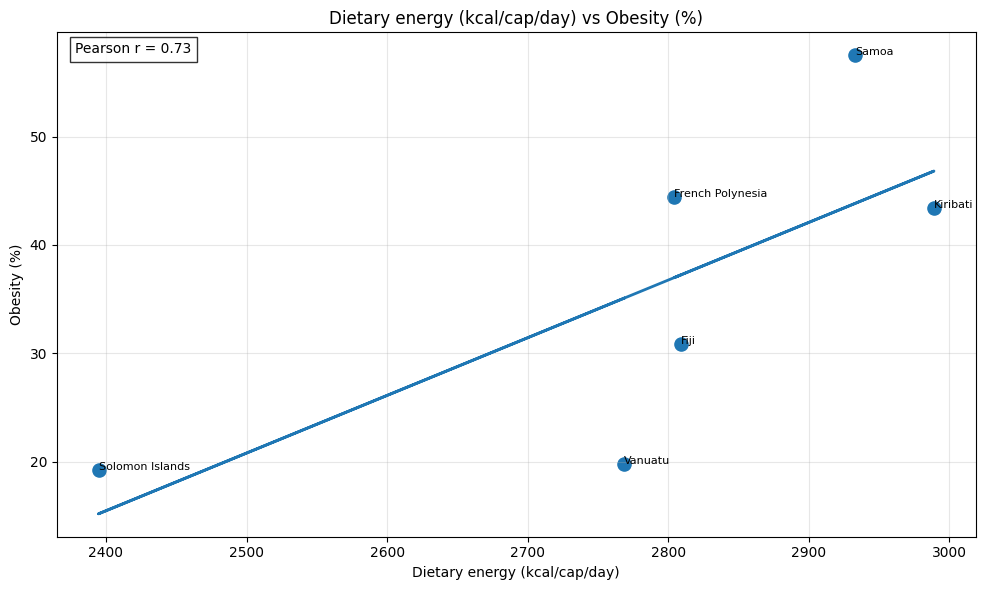

Countries included:
- Fiji
- French Polynesia
- Kiribati
- Samoa
- Solomon Islands
- Vanuatu


In [35]:
from scipy.stats import pearsonr

selected_filter = relationship_country_filter.value
selected_x = x_indicator_dropdown.value
selected_y = y_indicator_dropdown.value

if selected_x == "Select a food system indicator...":
    print("Please select a food system indicator for the x-axis.")

elif selected_y == "Select a metabolic health indicator...":
    print("Please select a metabolic health indicator for the y-axis.")

else:
    x_col, x_multiplier, x_unit = food_indicator_options[selected_x]
    y_col, y_multiplier, y_unit = health_indicator_options[selected_y]

    if selected_filter == "Use countries selected in Section 7":
        selected_countries = list(comparison_countries.value)

        if len(selected_countries) == 0:
            relationship_source = observatory.iloc[0:0].copy()
            print("No countries were selected in Section 7.")

        else:
            relationship_source = observatory[
                observatory["Country"].isin(selected_countries)
            ].copy()

    else:
        relationship_source = observatory.copy()

    relationship_data = (
        relationship_source[["Country", x_col, y_col]]
        .dropna()
        .copy()
    )

    if relationship_data.empty:
        print("No overlapping data are available for the selected countries and indicators.")

    else:
        relationship_summary = (
            relationship_data
            .groupby("Country")
            .agg({
                x_col: "mean",
                y_col: "mean"
            })
            .reset_index()
        )

        relationship_summary[x_col] = relationship_summary[x_col] * x_multiplier
        relationship_summary[y_col] = relationship_summary[y_col] * y_multiplier

        if len(relationship_summary) < 3:
            print("Not enough countries have overlapping data for a reliable scatterplot.")
            print("Countries with data:")
            for country_name in sorted(relationship_summary["Country"]):
                print(f"- {country_name}")

        else:
            r, p = pearsonr(
                relationship_summary[x_col],
                relationship_summary[y_col]
            )

            plt.figure(figsize=(10, 6))

            plt.scatter(
                relationship_summary[x_col],
                relationship_summary[y_col],
                s=90
            )

            for _, row in relationship_summary.iterrows():
                plt.text(
                    row[x_col],
                    row[y_col],
                    row["Country"],
                    fontsize=8
                )

            m, b = np.polyfit(
                relationship_summary[x_col],
                relationship_summary[y_col],
                1
            )

            plt.plot(
                relationship_summary[x_col],
                m * relationship_summary[x_col] + b,
                linewidth=2
            )

            plt.title(f"{selected_x} vs {selected_y}")
            plt.xlabel(selected_x)
            plt.ylabel(selected_y)
            plt.grid(alpha=0.3)

            plt.text(
                0.02,
                0.98,
                f"Pearson r = {r:.2f}",
                transform=plt.gca().transAxes,
                verticalalignment="top",
                bbox=dict(facecolor="white", alpha=0.8)
            )

            plt.tight_layout()
            plt.show()

            print("Countries included:")
            for country_name in sorted(relationship_summary["Country"]):
                print(f"- {country_name}")

# Section 9. Rankings Explorer

Rank countries by a selected indicator for a selected year.

This section allows users to identify which countries have the highest or lowest values for a given metabolic health, food system, or demographic indicator. Rankings are based only on countries with available data for the selected indicator and year.

In [36]:
ranking_indicator_dropdown = widgets.Dropdown(
    options=["Select an indicator..."] + list(indicator_options.keys()),
    value="Select an indicator...",
    description="Indicator:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="500px")
)

ranking_year_slider = widgets.IntSlider(
    value=int(observatory["Year"].max()),
    min=int(observatory["Year"].min()),
    max=int(observatory["Year"].max()),
    step=1,
    description="Year:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="500px")
)

ranking_order_dropdown = widgets.Dropdown(
    options=["Highest to lowest", "Lowest to highest"],
    value="Highest to lowest",
    description="Order:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="500px")
)

display(ranking_indicator_dropdown)
display(ranking_year_slider)
display(ranking_order_dropdown)

Dropdown(description='Indicator:', layout=Layout(width='500px'), options=('Select an indicator...', 'Obesity (…

IntSlider(value=2024, description='Year:', layout=Layout(width='500px'), max=2024, min=1980, style=SliderStyle…

Dropdown(description='Order:', layout=Layout(width='500px'), options=('Highest to lowest', 'Lowest to highest'…

In [38]:
selected_indicator = ranking_indicator_dropdown.value
selected_year = ranking_year_slider.value
selected_order = ranking_order_dropdown.value

if selected_indicator == "Select an indicator...":
    print("Please select an indicator.")

else:
    column, multiplier, unit = indicator_options[selected_indicator]

    ranking_data = (
        observatory[observatory["Year"] == selected_year]
        [["Country", column]]
        .dropna()
        .copy()
    )

    if ranking_data.empty:
        print(f"No data are available for {selected_indicator} in {selected_year}.")

    else:
        ranking_data[selected_indicator] = ranking_data[column] * multiplier

        ranking_data = ranking_data[["Country", selected_indicator]]

        ascending = selected_order == "Lowest to highest"

        ranking_data = (
            ranking_data
            .sort_values(selected_indicator, ascending=ascending)
            .reset_index(drop=True)
        )

        ranking_data.index = ranking_data.index + 1

        print(f"{selected_indicator} rankings for {selected_year}")
        print(f"Countries with available data: {len(ranking_data)}")

        display(ranking_data.round(2))

Obesity (%) rankings for 2024
Countries with available data: 16


,Country,Obesity (%)
1,American Samoa,76.89
2,Tonga,73.98
3,Cook Islands,73.50
4,Nauru,72.99
5,Tokelau,71.93
6,Niue,67.94
7,Tuvalu,66.44
8,Samoa,65.72
9,French Polynesia,50.24
10,Federated States of Micronesia,49.71


# Section 10. Transition to Dashboard Development

This notebook demonstrates the analytical components that will power the Pacific Nutrition Transition Explorer.

The visualizations, summaries, and interactive controls developed here have been validated using the integrated observatory dataset. The next phase of the project is to implement these components within a dedicated interactive dashboard that can be shared publicly.

The dashboard will use the same cleaned master dataset and will provide a streamlined interface for exploring Pacific nutrition transition trends, comparing countries, investigating relationships between food systems and metabolic health, and examining changes over time.

In [39]:
print("Notebook 9 complete.")
print("Prototype validated successfully.")
print("Ready for Notebook 10: Pacific Nutrition Transition Explorer Dashboard.")

Notebook 9 complete.
Prototype validated successfully.
Ready for Notebook 10: Pacific Nutrition Transition Explorer Dashboard.
